In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
# from gudhi.tensorflow import RipsLayer
from gudhi.representations import Landscape
# import tensorflow as tf
#import utils as u
import calendar 
from datetime import datetime
import matplotlib.dates as mdates

Plot the Takens-reconstructed attractor in 3D
Modify the code to visualize the embedded time series in 3D.
Construct synthetic data to compare against the snowfall time series

Create a simple 1D dynamical system that has "zero periods followed by a sharp bump."
Compare its delay-embedded attractor to your snowfall attractor.
Develop a null hypothesis model

Use a shuffled version of the snowfall data or another randomized model to test whether the topological features seen are meaningful.

In [2]:
#Loading in the Snow Data 
data = pd.read_csv("/Users/jamesmoukheiber/Documents/GitHub/tda-snow-capstone/cleaned.csv",index_col=0,header=None,skiprows=1)
data = data.iloc[:,1:].iloc[:-31]
print(data.columns)

Index([2], dtype='int64')


In [3]:

dates = []
start = 1
for year in range(2015,2025):
    if calendar.isleap(year):
        days = 366
    else:
        days = 365
    for day in range(1, days+1):
        day = str(day).zfill(3)
        res = datetime.strptime(str(year) + "-" + day, "%Y-%j").strftime("%m-%d-%Y")
        dates.append(res)
data['Date']=dates
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index("Date")
data.rename(columns={2: 'snow'}, inplace=True)


In [4]:
data

,snow
Date,
2015-01-01,0.000386
2015-01-02,0.175324
2015-01-03,1.424501
2015-01-04,1.132926
2015-01-05,2.866150
...,...
2024-12-27,0.078915
2024-12-28,0.122403
2024-12-29,0.162725


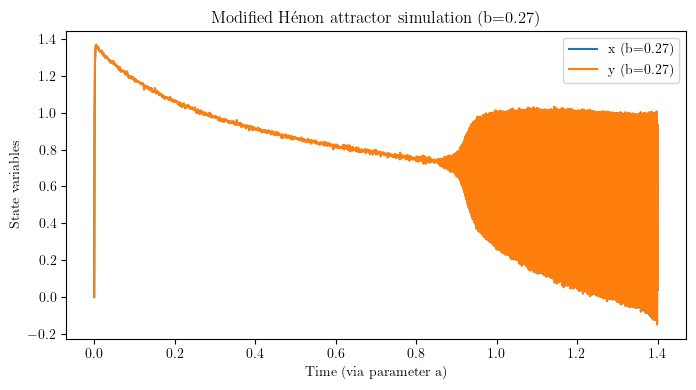

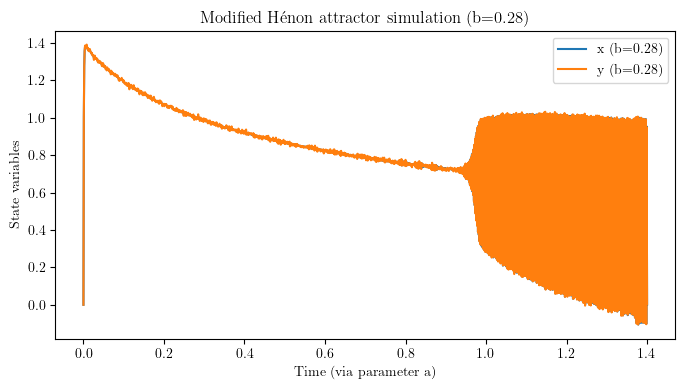

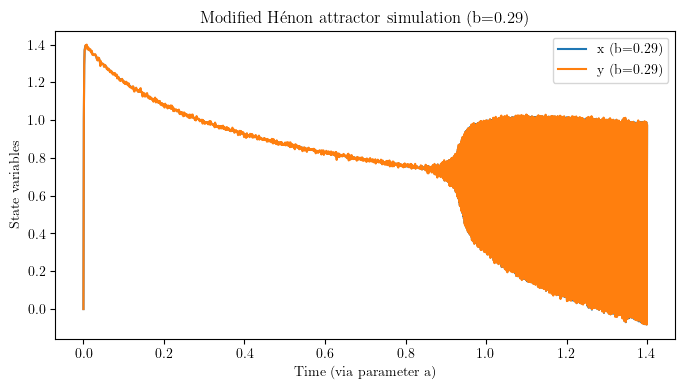

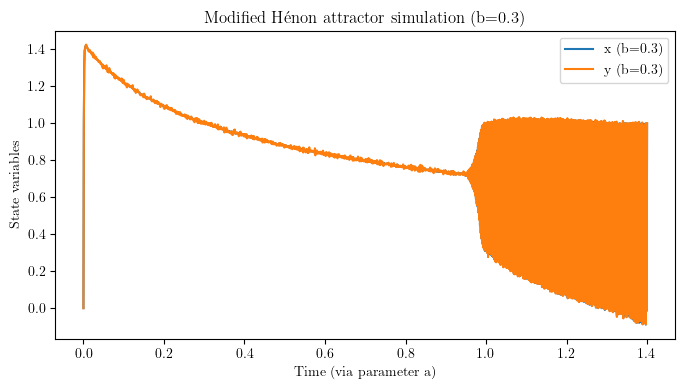

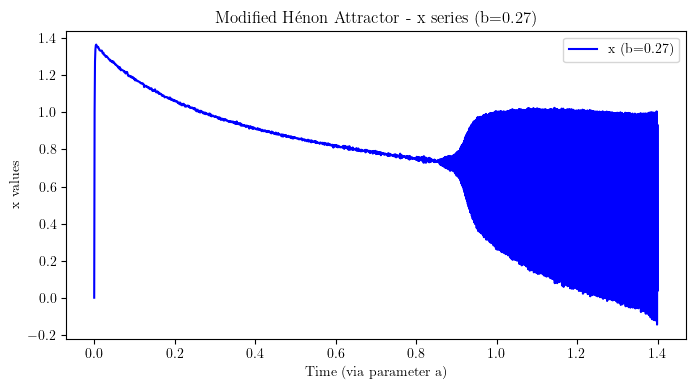

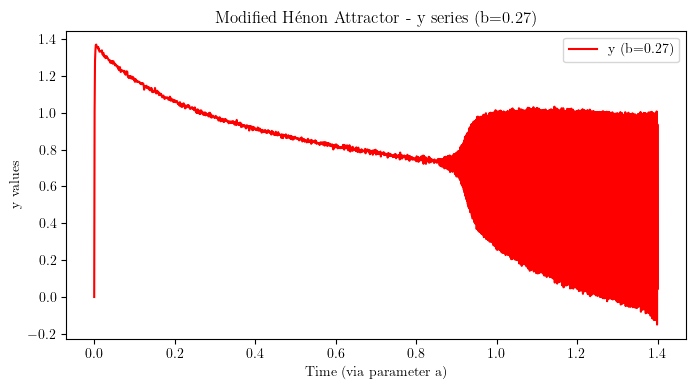

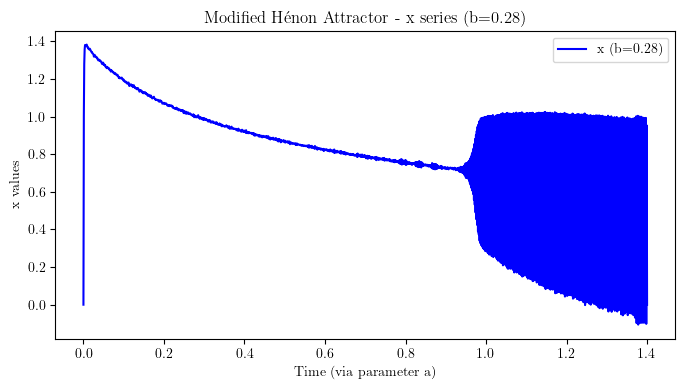

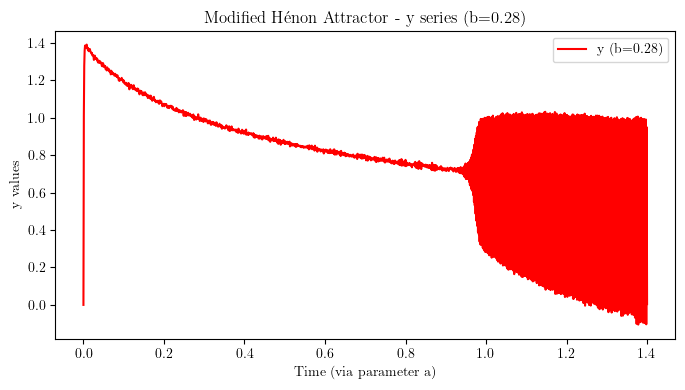

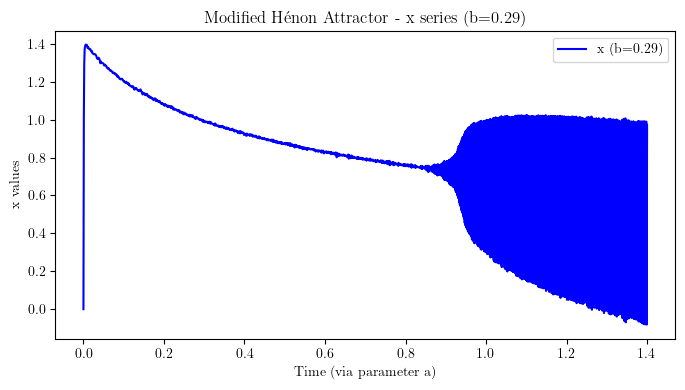

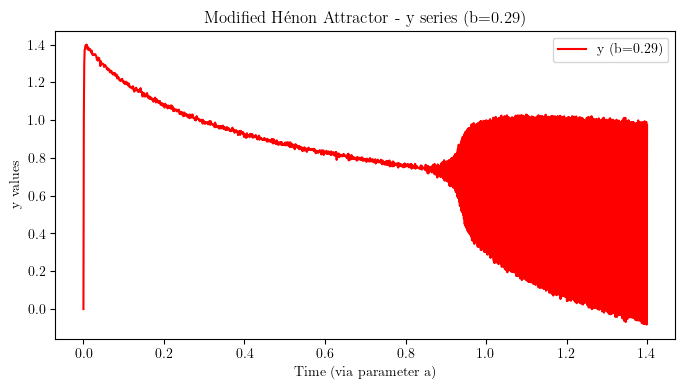

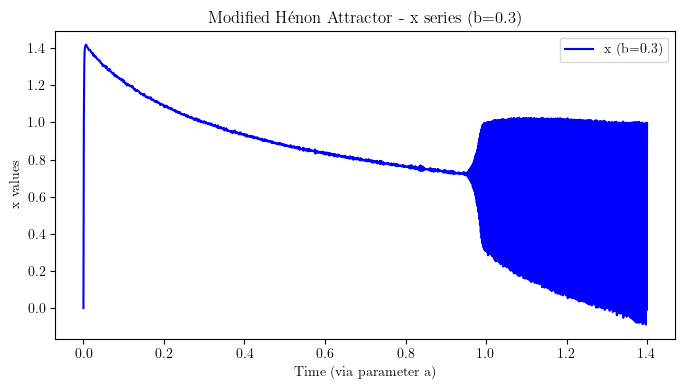

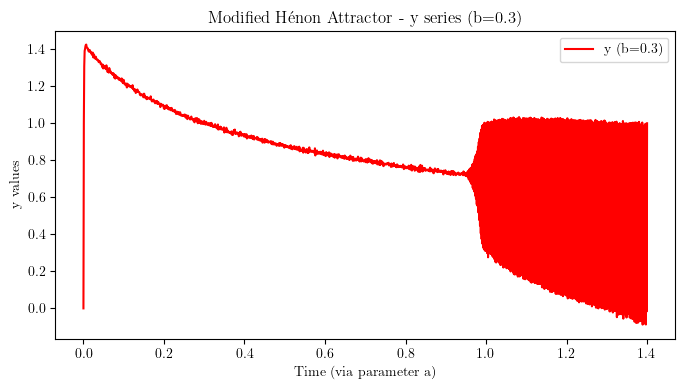

In [80]:
## Simulating our Dynamical System 
## Originally From https://arxiv.org/pdf/1703.04385, edited. 

import numpy as np
import matplotlib.pyplot as plt

def simulate_henon(a_start=0.0, a_end=1.4, dt=0.001, b=0.3, sigma=0.1, x0=0.0, y0=0.0):
    """
    Simulate the modified Hénon attractor (Equation 3.2) with linearly increasing 'a' and Gaussian noise.
    
    Parameters:
        a_start (float): Initial value of parameter a.
        a_end   (float): Final value of parameter a (stop when a reaches this value).
        dt      (float): Time step for each iteration (increment for a per step).
        b       (float): Parameter b (kept constant during the simulation).
        sigma   (float): Noise intensity (std. deviation of the Gaussian noise added each step).
        x0      (float): Initial x value.
        y0      (float): Initial y value.
    
    Returns:
        (x_values, y_values, a_values):
            x_values (np.ndarray): Time series of x values.
            y_values (np.ndarray): Time series of y values.
            a_values (np.ndarray): Time series of a values (acts as the time axis).
    """
    # number of steps based on the range of a and time step
    steps = int(np.ceil((a_end - a_start) / dt))
    
    #  arrays to store results
    x_values = np.zeros(steps + 1)
    y_values = np.zeros(steps + 1)
    a_values = np.zeros(steps + 1)
    
    #  initial conditions
    x_values[0], y_values[0], a_values[0] = x0, y0, a_start
    
    #  state variables
    x, y, a = x0, y0, a_start
    for n in range(steps):
        #  noise from a standard normal distribution, 
        # Playing with Wn to see if we can better replicate snowfall data 
        bern = np.random.binomial(1, p=0.01)
    
        #Wn = bern * np.random.normal(loc=0.0, scale=1.0) #Also Bad 
        #Wn = bern * np.random.exponential(scale=5.0)  #Kind of Bad 
        Wn = np.random.normal(loc=0.0, scale=1.0)     # Okay 
        
        # Update equations (Henon map with current a and noise)
        x_new = 1 - a * x**2 + b * y + sigma * Wn * np.sqrt(dt)
        y_new = x_new + sigma * Wn * np.sqrt(dt)
        a_new = a + dt  # increment a linearly
        
        #store new state
        x_values[n+1] = x_new
        y_values[n+1] = y_new
        a_values[n+1] = a_new
        
        # update variables for next iteration
        x, y, a = x_new, y_new, a_new
        
        # end if we've reached (or exceeded) the target a_end
        if a >= a_end:
            # trim arrays to the actual length  (n+2 elements: index 0 through n+1)
            x_values = x_values[:n+2]
            y_values = y_values[:n+2]
            a_values = a_values[:n+2]
            break
    
    return x_values, y_values, a_values

# simulate for each b value and plot the results
b_values = [0.27, 0.28, 0.29, 0.3]

np.random.seed(0)

results = {}  # dictionary for each b
for b in b_values:
    #  simulation for this b
    x_series, y_series, a_series = simulate_henon(b=b, sigma=0.1, dt=0.001)
    results[b] = {"x": x_series, "y": y_series, "a": a_series}
    
    # Plot time series using 'a' as the time axis
    plt.figure(figsize=(8,4))
    plt.plot(a_series, x_series, label=f"x (b={b})")
    plt.plot(a_series, y_series, label=f"y (b={b})")
    plt.title(f"Modified Hénon attractor simulation (b={b})")
    plt.xlabel("Time (via parameter a)")
    plt.ylabel("State variables")
    plt.legend()
    plt.show()


for b in b_values:
    x_series = results[b]["x"]
    y_series = results[b]["y"]
    a_series = results[b]["a"]

    #  x time 
    plt.figure(figsize=(8, 4))
    plt.plot(a_series, x_series, label=f"x (b={b})", color='blue')
    plt.title(f"Modified Hénon Attractor - x series (b={b})")
    plt.xlabel("Time (via parameter a)")
    plt.ylabel("x values")
    plt.legend()
    plt.show()

    #  y time 
    plt.figure(figsize=(8, 4))
    plt.plot(a_series, y_series, label=f"y (b={b})", color='red')
    plt.title(f"Modified Hénon Attractor - y series (b={b})")
    plt.xlabel("Time (via parameter a)")
    plt.ylabel("y values")
    plt.legend()
    plt.show()




In [81]:
# 4 realizations of the x_series for each b value per the paper 
num_realizations = 4
realizations = {b: [] for b in b_values}

for b in b_values:
    for _ in range(num_realizations):
        x_series, _, a_series = simulate_henon(b=b, sigma=0.1, dt=0.001)
        realizations[b].append(x_series)


for b in b_values:
    realizations[b] = np.array(realizations[b])  # shape (4, num_time_steps)


for b in b_values:
    print(f"b={b}: {realizations[b].shape}") 


b=0.27: (4, 1401)
b=0.28: (4, 1401)
b=0.29: (4, 1401)
b=0.3: (4, 1401)


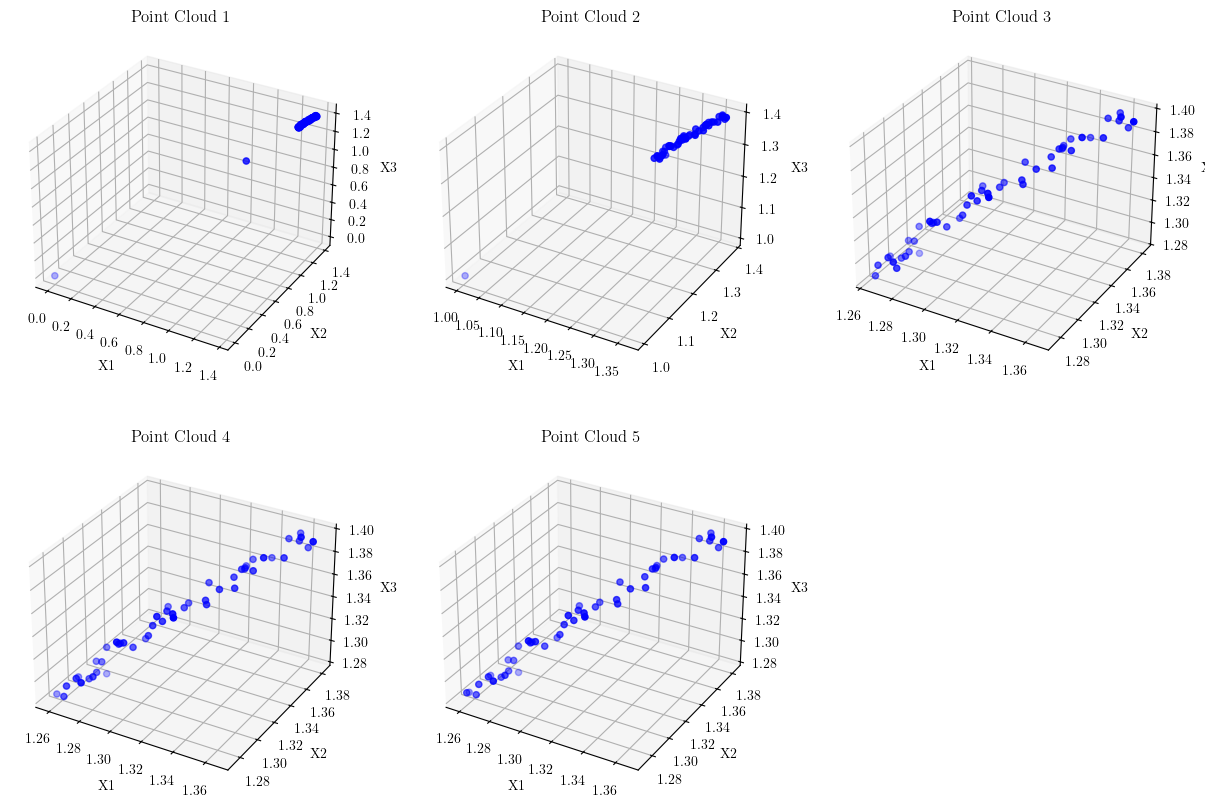

In [82]:
### 3d Plots of First 5 Point clouds of X-series 

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


w = 50  
d = len(b_values) 


x_series_dict = {b: results[b]["x"] for b in b_values}


min_length = min(len(x_series) for x_series in x_series_dict.values())
for b in b_values:
    x_series_dict[b] = x_series_dict[b][:min_length]


point_clouds = []  

for n in range(min_length - w + 1):  
    Xn = np.column_stack([x_series_dict[b][n:n+w] for b in b_values])
    point_clouds.append(Xn)  # Store the point cloud


num_plots = min(5, len(point_clouds))  
fig = plt.figure(figsize=(15, 10))

for i in range(num_plots):
    ax = fig.add_subplot(2, 3, i+1, projection='3d')
    ax.scatter(point_clouds[i][:, 0], point_clouds[i][:, 1], point_clouds[i][:, 2], c='b', marker='o')
    ax.set_title(f'Point Cloud {i+1}')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')

plt.show()


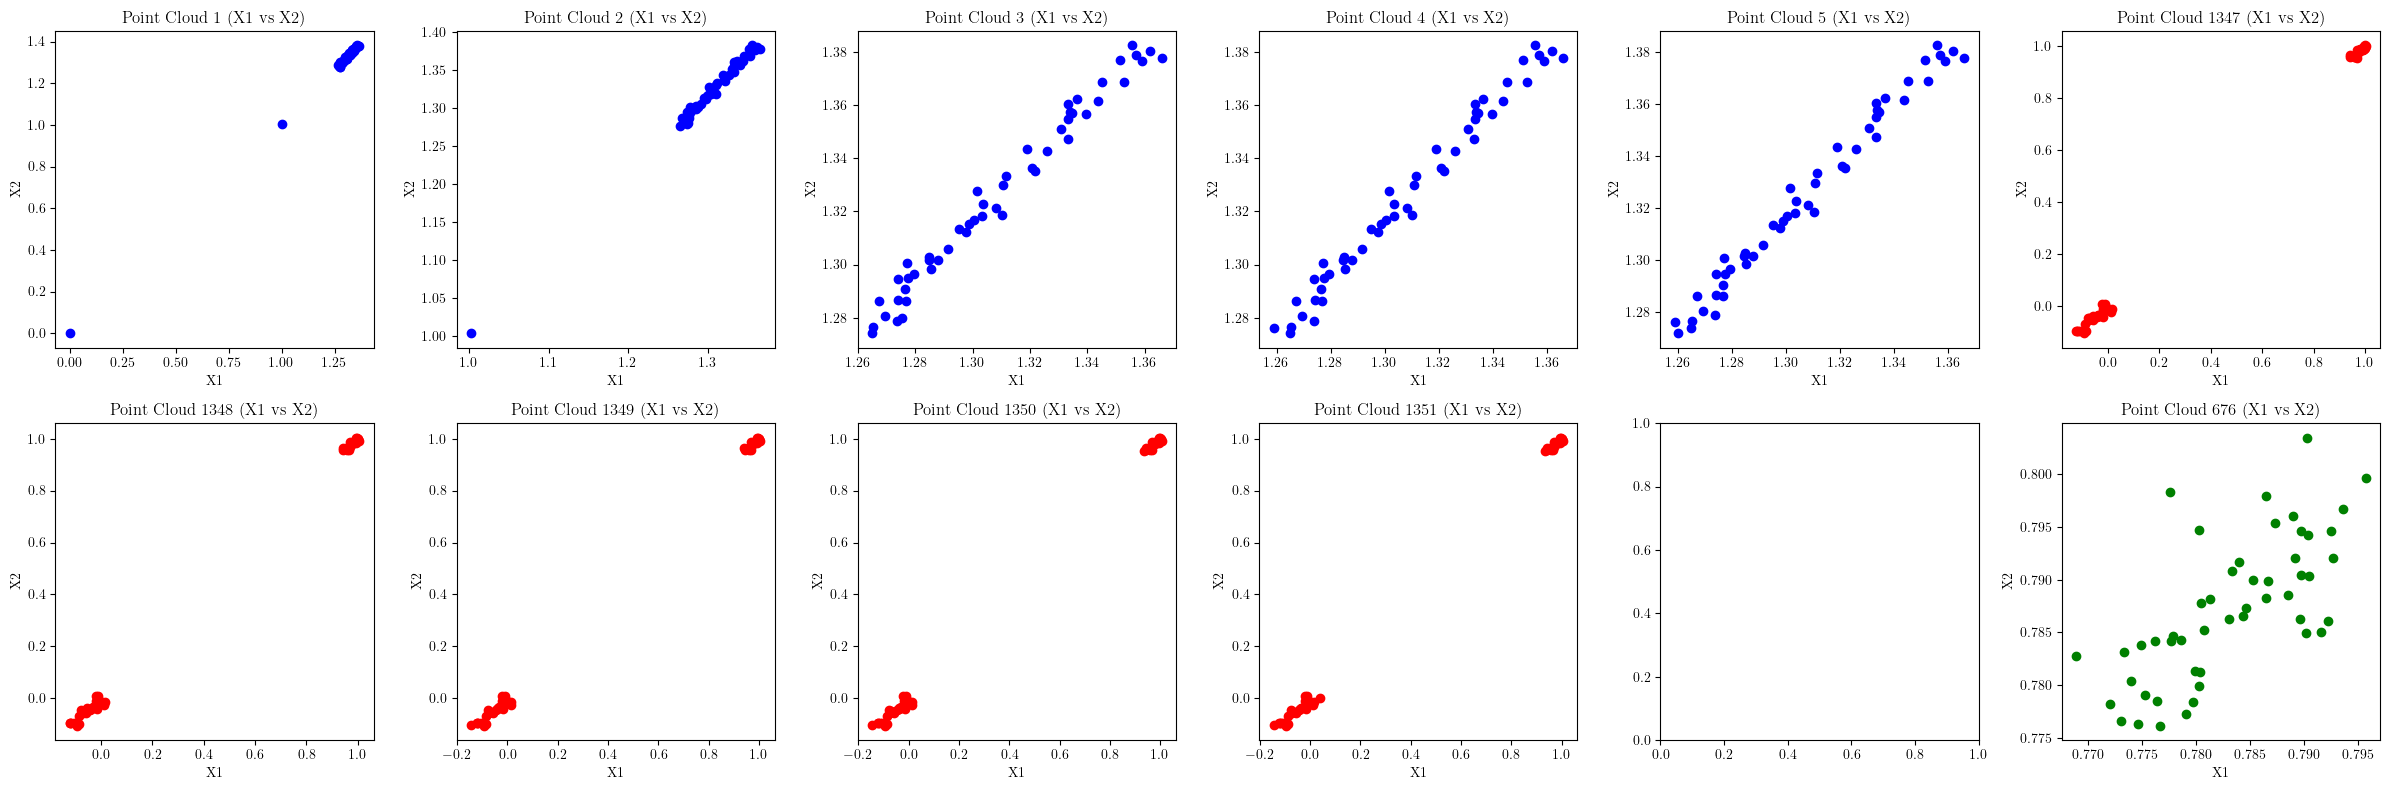

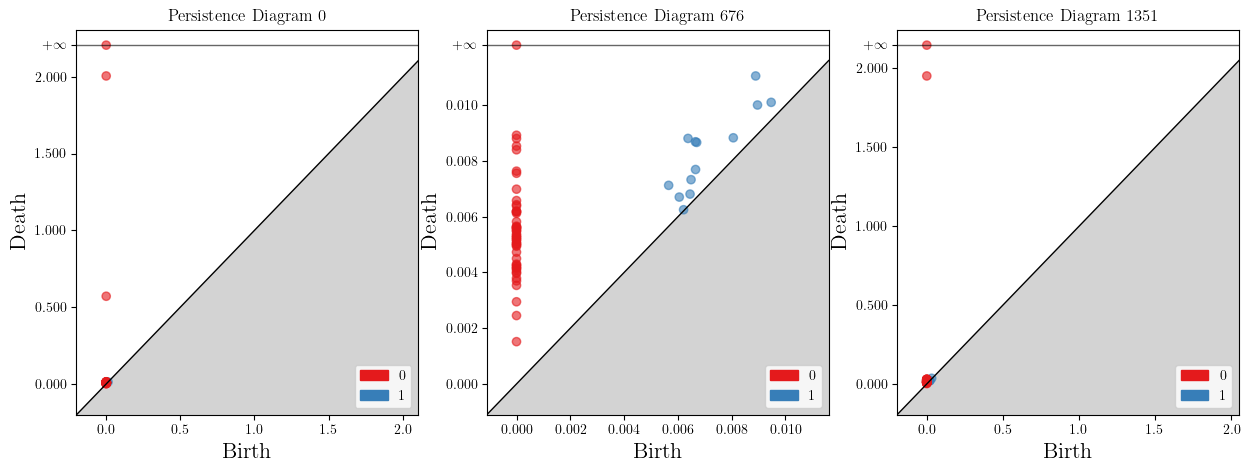

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

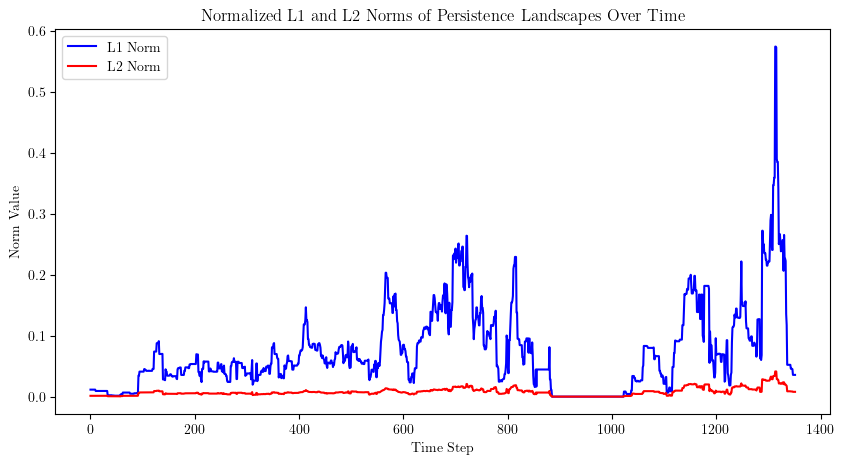

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
import gudhi.representations


w = 50  #window
d = len(b_values)  # dimension of each point

# get x-series for each b value
x_series_dict = {b: results[b]["x"] for b in b_values}

#  all time series are same length
min_length = min(len(x_series) for x_series in x_series_dict.values())
for b in b_values:
    x_series_dict[b] = x_series_dict[b][:min_length]


point_clouds = []  

for n in range(min_length - w + 1):  #valid window
    Xn = np.column_stack([x_series_dict[b][n:n+w] for b in b_values])
    point_clouds.append(Xn)  


num_plots = min(5, len(point_clouds))  #
fig, axes = plt.subplots(2, 6, figsize=(24, 8))  
axes = axes.flatten()

# first 5 point clouds
for i in range(num_plots):
    ax = axes[i]
    ax.scatter(point_clouds[i][:, 0], point_clouds[i][:, 1], c='b', marker='o')
    ax.set_title(f'Point Cloud {i+1} (X1 vs X2)')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')

# last 5 point clouds
for i in range(num_plots):
    ax = axes[i + 5]
    ax.scatter(point_clouds[-(num_plots - i)][:, 0], point_clouds[-(num_plots - i)][:, 1], c='r', marker='o')
    ax.set_title(f'Point Cloud {len(point_clouds) - (num_plots - i)} (X1 vs X2)')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')

# middle PC 
if len(point_clouds) > 676:
    ax = axes[-1]
    ax.scatter(point_clouds[676][:, 0], point_clouds[676][:, 1], c='g', marker='o')
    ax.set_title(f'Point Cloud 676 (X1 vs X2)')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')

plt.tight_layout()
plt.show()


selected_indices = [0, len(point_clouds)//2, len(point_clouds)-1]  
selected_indices = [idx for idx in selected_indices if idx < len(point_clouds)] 
fig, axes = plt.subplots(1, len(selected_indices), figsize=(15, 5))

landscapes = []  

for i, idx in enumerate(selected_indices):
    rips = gd.RipsComplex(points=point_clouds[idx])
    st = rips.create_simplex_tree(max_dimension=2)
    dgm = st.persistence()
    gd.plot_persistence_diagram(dgm, axes=axes[i])
    axes[i].set_title(f'Persistence Diagram {idx}')
    
    #  persistence landscape
    pers_landscape = gd.representations.Landscape()
    landscapes.append(pers_landscape.fit_transform([st.persistence_intervals_in_dimension(1)]))

plt.show()


l1_norms_landscape = []
l2_norms_landscape = []

for pc in point_clouds:
    rips = gd.RipsComplex(points=pc)
    st = rips.create_simplex_tree(max_dimension=2)
    st.persistence()
    pers_landscape = gd.representations.Landscape()
    landscape = pers_landscape.fit_transform([st.persistence_intervals_in_dimension(1)])
    
    l1_norms_landscape.append(np.sum(np.abs(landscape)))
    l2_norms_landscape.append(np.sqrt(np.sum(landscape**2)))


#  normalized L1 and L2 norms 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(l1_norms_landscape, label='L1 Norm', color='blue')
ax.plot(l2_norms_landscape, label='L2 Norm', color='red')
ax.set_title('Normalized L1 and L2 Norms of Persistence Landscapes Over Time')
ax.set_xlabel('Time Step')
ax.set_ylabel('Norm Value')
ax.legend()

plt.show()
